# UW / FRF NetCDF Corpus
## Full-dataset loading, EDA, and first-run processing notebook

### What this notebook does
1. discovers and extracts the available NetCDF sources,
2. inventories file families and schema variants,
3. performs first-pass quality checks,
4. generates EDA plots and summary tables,
5. creates standardized processing outputs for downstream modeling.

### Key dataset assumptions reflected here
- The attached Schanta thesis documents the same FUNWAVE-TVD corpus generation workflow: Duck FRF bathymetries, 8-m array spectra, and a large ensemble of roughly 20,000 runs used to model nearshore skewness and asymmetry.
- A negative `profileNumber` is **not automatically an error**. In the Duck FRF local coordinate system, one of the frequently surveyed “four lines” is located at `yFRF = -91`, so negative profile numbers can be physically legitimate in this corpus.
- The sample provider explicitly noted a likely typo in `Z_orig`; this notebook therefore treats `Z_wedge` / `Z_interp` as the reliable reduced-profile bathymetry fields for first-pass modeling.

### Processing philosophy
This notebook keeps the **raw time-series branch** and the **reduced-statistics branch** separate.  
That is the safest way to do a first full run before a final supervised shoreline target table is defined.

In [1]:
from pathlib import Path
import json
import math
import os
import re
import shutil
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)

ROOT = Path.cwd()

# ---- user configuration -----------------------------------------------------

SOURCE_PATHS = [
]

FORCE_REEXTRACT = False
MAX_FILES = None                 
ANALYSIS_Y_INDEX = 1
NORM_GRID_SIZE = 200
RAW_EXAMPLE_COUNT = 3
EXPORT_PROCESSED_TABLES = True
EXPORT_LONG_TABLES = True

WORK_DIR = ROOT / "uw_frf_eda_workspace"
EXTRACT_DIR = WORK_DIR / "extracted"
OUTPUT_DIR = ROOT / "uw_frf_eda_outputs"
FIG_DIR = OUTPUT_DIR / "figures"

WORK_DIR.mkdir(exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"WORK_DIR: {WORK_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

ROOT: /mnt/data
WORK_DIR: /mnt/data/uw_frf_eda_workspace
OUTPUT_DIR: /mnt/data/uw_frf_eda_outputs


In [2]:
def slugify(text: str) -> str:
    text = re.sub(r"[^A-Za-z0-9]+", "_", str(text)).strip("_")
    return text or "source"

def scalarize(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore")
    if isinstance(value, np.ndarray):
        if value.size == 1:
            return scalarize(value.reshape(-1)[0])
        return [scalarize(v) for v in value.reshape(-1)]
    if isinstance(value, np.generic):
        return value.item()
    return value

def maybe_datetime(value):
    if value in (None, "", "nan"):
        return pd.NaT
    return pd.to_datetime(value, errors="coerce")

def open_ds(path: Path) -> xr.Dataset:
    return xr.open_dataset(path, engine="h5netcdf")

def required_sources(source_paths):
    cleaned = [Path(p) for p in source_paths if Path(p).exists()]
    if cleaned:
        return cleaned

    auto = []
    auto.extend(sorted(ROOT.glob("*.zip")))
    auto.extend(sorted({p.parent for p in ROOT.rglob("*.nc") if OUTPUT_DIR not in p.parents and WORK_DIR not in p.parents}))
    auto = [p for p in auto if p.exists()]
    return auto

def materialize_sources(sources):
    materialized = []
    for src in sources:
        src = Path(src)
        if src.suffix.lower() == ".zip":
            dest = EXTRACT_DIR / slugify(src.stem)
            if FORCE_REEXTRACT and dest.exists():
                shutil.rmtree(dest)
            if not dest.exists():
                print(f"Extracting {src.name} -> {dest}")
                dest.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(src, "r") as zf:
                    zf.extractall(dest)
            materialized.append({"source": src.name, "kind": "zip", "path": dest})
        elif src.is_dir():
            materialized.append({"source": src.name, "kind": "dir", "path": src})
    return materialized

def infer_family_from_vars(var_names):
    var_names = set(var_names)
    if {"Sk_int", "As_int", "Z_interp", "Z_wedge"}.issubset(var_names):
        return "stats"
    if {"eta", "mask", "nubrk", "Z", "U_undertow", "roller"}.issubset(var_names):
        return "tri_full"
    if {"eta", "mask", "nubrk", "Z"}.issubset(var_names):
        return "tri_small"
    return "other_nc"

def summarize_netcdf(path: Path, source_name: str) -> dict:
    with open_ds(path) as ds:
        sizes = {k: int(v) for k, v in ds.sizes.items()}
        vars_ = list(ds.data_vars)
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        family = infer_family_from_vars(vars_)

        return {
            "source_name": source_name,
            "relative_path": str(path),
            "file": path.name,
            "family": family,
            "dims_json": json.dumps(sizes, sort_keys=True),
            "vars_json": json.dumps(sorted(vars_)),
            "attr_count": len(attrs),
            "period_len": sizes.get("period"),
            "x_len": sizes.get("X"),
            "x_orig_len": sizes.get("X_orig"),
            "x_wedge_len": sizes.get("X_wedge"),
            "x_interp_len": sizes.get("X_interp"),
            "t_len": sizes.get("t_FW"),
            "y_len": sizes.get("Y"),
            "Hs": attrs.get("Hs"),
            "PeakPeriod": attrs.get("PeakPeriod"),
            "DX": attrs.get("DX"),
            "TOTAL_TIME": attrs.get("TOTAL_TIME"),
            "t_prop": attrs.get("t_prop"),
            "surveyNumber": attrs.get("surveyNumber"),
            "profileNumber": attrs.get("profileNumber"),
            "ba_date_str": attrs.get("ba_date_str"),
            "sp_date_str": attrs.get("sp_date_str"),
            "has_Z_orig": "Z_orig" in ds.data_vars,
            "has_undertow": "U_undertow" in ds.data_vars,
            "has_roller": "roller" in ds.data_vars,
            "has_stats_interp": "Z_interp" in ds.data_vars,
        }

sources = required_sources(SOURCE_PATHS)
if not sources:
    raise FileNotFoundError("No sources found. Place the notebook next to your zip files or set SOURCE_PATHS manually.")

materialized = materialize_sources(sources)
print("Materialized sources:")
for item in materialized:
    print(f" - {item['source']} ({item['kind']}) -> {item['path']}")

nc_files = []
for item in materialized:
    root_path = item["path"]
    found = sorted(root_path.rglob("*.nc"))
    for p in found:
        nc_files.append((item["source"], p))

if MAX_FILES is not None:
    nc_files = nc_files[:MAX_FILES]

print(f"\nNetCDF files discovered: {len(nc_files)}")
for src_name, p in nc_files[:10]:
    print(f" - [{src_name}] {p.name}")

Materialized sources:
 - Sample Data.zip (zip) -> /mnt/data/uw_frf_eda_workspace/extracted/Sample_Data
 - temp_2.zip (zip) -> /mnt/data/uw_frf_eda_workspace/extracted/temp_2

NetCDF files discovered: 24
 - [Sample Data.zip] stats_00001.nc
 - [Sample Data.zip] stats_02930.nc
 - [Sample Data.zip] tri_00002.nc
 - [Sample Data.zip] tri_03020.nc
 - [temp_2.zip] nc_small_ali_00001.nc
 - [temp_2.zip] nc_small_ali_00002.nc
 - [temp_2.zip] nc_small_ali_00003.nc
 - [temp_2.zip] nc_small_ali_00004.nc
 - [temp_2.zip] nc_small_ali_00005.nc
 - [temp_2.zip] nc_small_ali_00006.nc


## 1. Inventory, schema audit, and QA notes
The next cells create a reproducible inventory of the corpus and identify schema differences that matter for downstream processing.

In [3]:
inventory_rows = []
for idx, (src_name, path) in enumerate(nc_files, start=1):
    if idx % 50 == 0 or idx == 1 or idx == len(nc_files):
        print(f"Summarizing file {idx:,} / {len(nc_files):,}")
    inventory_rows.append(summarize_netcdf(path, src_name))

inventory_df = pd.DataFrame(inventory_rows)
inventory_df["ba_date"] = pd.to_datetime(inventory_df["ba_date_str"], errors="coerce")
inventory_df["sp_date"] = pd.to_datetime(inventory_df["sp_date_str"], errors="coerce")

inventory_df.to_csv(OUTPUT_DIR / "file_inventory.csv", index=False)

print("Inventory by source and family")
display(inventory_df.groupby(["source_name", "family"]).size().reset_index(name="files"))

print("\nInventory head")
display(inventory_df.head())

Summarizing file 1 / 24


Summarizing file 24 / 24
Inventory by source and family


,source_name,family,files
0,Sample Data.zip,stats,2
1,Sample Data.zip,tri_full,2
2,temp_2.zip,tri_small,20



Inventory head


,source_name,relative_path,file,family,dims_json,vars_json,attr_count,period_len,x_len,x_orig_len,x_wedge_len,x_interp_len,t_len,y_len,Hs,PeakPeriod,DX,TOTAL_TIME,t_prop,surveyNumber,profileNumber,ba_date_str,sp_date_str,has_Z_orig,has_undertow,has_roller,has_stats_interp,ba_date,sp_date
0,Sample Data.zip,/mnt/data/uw_frf_eda_workspace/extracted/Sample_Data/stats_00001.nc,stats_00001.nc,stats,"{""X_interp"": 200, ""X_orig"": 873, ""X_wedge"": 617, ""period"": 62}","[""As_int"", ""As_wedge"", ""Sk_int"", ""Sk_wedge"", ""Z_interp"", ""Z_orig"", ""Z_wedge"", ""amp"", ""phase""]",69,62,NaN,873.0,617.0,200.0,NaN,NaN,2.9293,10.0000,1.1974,1170.2830,146.2854,1270.0,274.0,04/17/2023,01/21/2002 06:00,True,False,False,True,2023-04-17,2002-01-21 06:00:00
1,Sample Data.zip,/mnt/data/uw_frf_eda_workspace/extracted/Sample_Data/stats_02930.nc,stats_02930.nc,stats,"{""X_interp"": 200, ""X_orig"": 881, ""X_wedge"": 609, ""period"": 62}","[""As_int"", ""As_wedge"", ""Sk_int"", ""Sk_wedge"", ""Z_interp"", ""Z_orig"", ""Z_wedge"", ""amp"", ""phase""]",69,62,NaN,881.0,609.0,200.0,NaN,NaN,1.3206,10.8108,1.3051,1248.4462,156.0558,1105.0,-91.0,09/15/2015,01/21/2002 06:00,True,False,False,True,2015-09-15,2002-01-21 06:00:00
2,Sample Data.zip,/mnt/data/uw_frf_eda_workspace/extracted/Sample_Data/tri_00002.nc,tri_00002.nc,tri_full,"{""X"": 896, ""Y"": 3, ""period"": 62, ""t_FW"": 8175}","[""U_undertow"", ""V_undertow"", ""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase"", ""roller""]",69,62,896.0,NaN,NaN,NaN,8175.0,3.0,0.9954,10.0000,1.1974,1226.2471,153.2809,1209.0,1052.0,08/23/2021,01/21/2002 06:00,False,True,True,False,2021-08-23,2002-01-21 06:00:00
3,Sample Data.zip,/mnt/data/uw_frf_eda_workspace/extracted/Sample_Data/tri_03020.nc,tri_03020.nc,tri_full,"{""X"": 1160, ""Y"": 3, ""period"": 62, ""t_FW"": 9533}","[""U_undertow"", ""V_undertow"", ""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase"", ""roller""]",69,62,1160.0,NaN,NaN,NaN,9533.0,3.0,0.5884,8.1633,0.9496,1429.9363,178.7420,982.0,1.0,01/01/2004,01/21/2002 06:00,False,True,True,False,2004-01-01,2002-01-21 06:00:00
4,temp_2.zip,/mnt/data/uw_frf_eda_workspace/extracted/temp_2/temp_2/nc_small_ali_00001.nc,nc_small_ali_00001.nc,tri_small,"{""X"": 725, ""period"": 62, ""t_FW"": 7686}","[""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""]",69,62,725.0,NaN,NaN,NaN,7686.0,NaN,1.6285,14.2857,1.7603,1152.8393,144.1049,1069.0,777.0,02/14/2012,01/21/2002 06:00,False,False,False,False,2012-02-14,2002-01-21 06:00:00


In [4]:
schema_rows = []
for family, sub in inventory_df.groupby("family"):
    dims_counter = Counter(sub["dims_json"])
    vars_counter = Counter(sub["vars_json"])

    schema_rows.append({
        "family": family,
        "files": len(sub),
        "unique_dim_signatures": len(dims_counter),
        "most_common_dims": dims_counter.most_common(3),
        "unique_var_signatures": len(vars_counter),
        "most_common_vars": vars_counter.most_common(3),
    })

schema_df = pd.DataFrame(schema_rows)
schema_df.to_csv(OUTPUT_DIR / "schema_summary.csv", index=False)

display(schema_df)

,family,files,unique_dim_signatures,most_common_dims,unique_var_signatures,most_common_vars
0,stats,2,2,"[({""X_interp"": 200, ""X_orig"": 873, ""X_wedge"": 617, ""period"": 62}, 1), ({""X_interp"": 200, ""X_orig"": 881, ""X_wedge"": 609, ""period"": 62}, 1)]",1,"[([""As_int"", ""As_wedge"", ""Sk_int"", ""Sk_wedge"", ""Z_interp"", ""Z_orig"", ""Z_wedge"", ""amp"", ""phase""], 2)]"
1,tri_full,2,2,"[({""X"": 896, ""Y"": 3, ""period"": 62, ""t_FW"": 8175}, 1), ({""X"": 1160, ""Y"": 3, ""period"": 62, ""t_FW"": 9533}, 1)]",1,"[([""U_undertow"", ""V_undertow"", ""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase"", ""roller""], 2)]"
2,tri_small,20,20,"[({""X"": 725, ""period"": 62, ""t_FW"": 7686}, 1), ({""X"": 896, ""period"": 62, ""t_FW"": 8175}, 1), ({""X"": 675, ""period"": 62, ""t_FW"": 7526}, 1)]",1,"[([""Z"", ""amp"", ""eta"", ""mask"", ""nubrk"", ""phase""], 20)]"


In [5]:
qa_findings = []

for _, row in inventory_df.iterrows():
    family = row["family"]
    file_name = row["file"]

    if row["period_len"] not in (None, 62):
        qa_findings.append({"file": file_name, "severity": "warn", "check": "period_len", "detail": f"Unexpected period length: {row['period_len']}"})

    if family == "stats":
        if row["x_interp_len"] != 200:
            qa_findings.append({"file": file_name, "severity": "warn", "check": "x_interp_len", "detail": f"Expected 200-point standardized profile, found {row['x_interp_len']}"})
        if row["has_Z_orig"]:
            qa_findings.append({"file": file_name, "severity": "info", "check": "Z_orig", "detail": "Provider script notes likely typo in Z_orig; prefer Z_wedge / Z_interp for first-pass modeling."})

    if family in ("tri_full", "tri_small"):
        if pd.notna(row["t_prop"]) and pd.notna(row["TOTAL_TIME"]) and row["t_prop"] >= row["TOTAL_TIME"]:
            qa_findings.append({"file": file_name, "severity": "warn", "check": "t_prop_vs_total_time", "detail": "t_prop should normally be smaller than TOTAL_TIME."})

    if pd.notna(row["profileNumber"]) and row["profileNumber"] < 0:
        qa_findings.append({"file": file_name, "severity": "info", "check": "negative_profile_number", "detail": "Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."})

qa_df = pd.DataFrame(qa_findings)
qa_df.to_csv(OUTPUT_DIR / "qa_findings.csv", index=False)

display(qa_df.head(20))
print(f"\nQA findings recorded: {len(qa_df):,}")

,file,severity,check,detail
0,stats_00001.nc,info,Z_orig,Provider script notes likely typo in Z_orig; prefer Z_wedge / Z_interp for first-pass modeling.
1,stats_02930.nc,info,Z_orig,Provider script notes likely typo in Z_orig; prefer Z_wedge / Z_interp for first-pass modeling.
2,stats_02930.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."
3,nc_small_ali_00015.nc,info,negative_profile_number,"Negative profileNumber can be valid in Duck FRF coordinates (e.g., yFRF = -91 four-line transect)."



QA findings recorded: 4


## 2. Corpus-level EDA

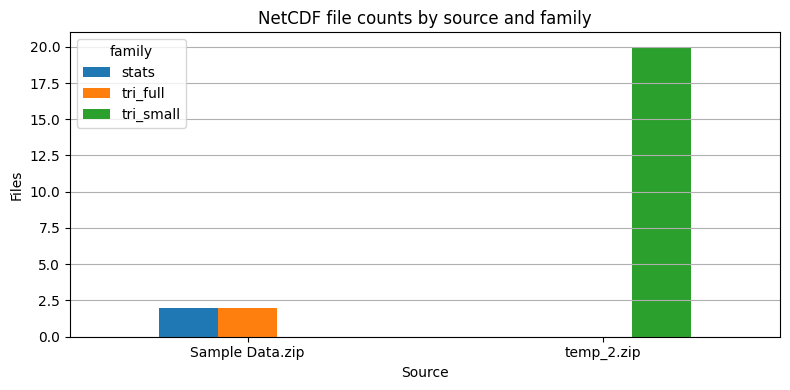

In [6]:
family_counts = inventory_df.groupby(["source_name", "family"]).size().unstack(fill_value=0)
ax = family_counts.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("NetCDF file counts by source and family")
ax.set_xlabel("Source")
ax.set_ylabel("Files")
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_counts_by_source_family.png", dpi=180, bbox_inches="tight")
plt.show()

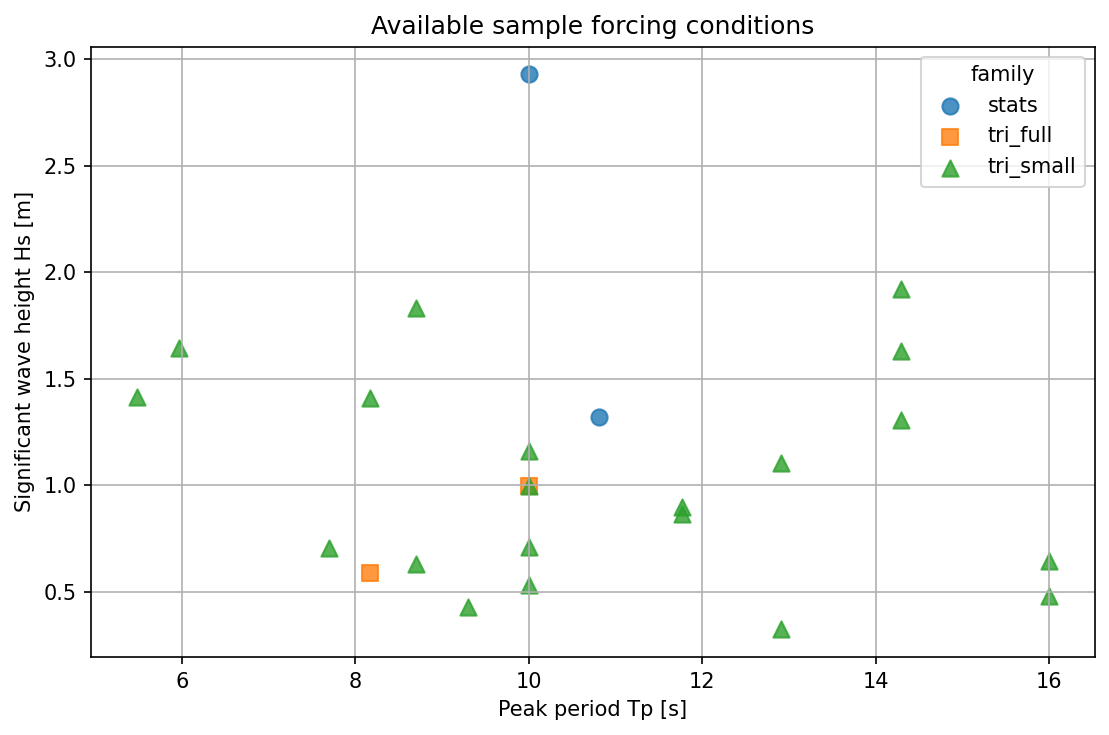

In [7]:
plot_df = inventory_df.dropna(subset=["Hs", "PeakPeriod"]).copy()

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
markers = {"stats": "o", "tri_full": "s", "tri_small": "^", "other_nc": "x"}
for family, sub in plot_df.groupby("family"):
    ax.scatter(sub["PeakPeriod"], sub["Hs"], label=family, marker=markers.get(family, "o"), s=60, alpha=0.8)

ax.set_title("Available sample forcing conditions")
ax.set_xlabel("Peak period Tp [s]")
ax.set_ylabel("Significant wave height Hs [m]")
ax.grid(True)
ax.legend(title="family")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_hs_tp_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

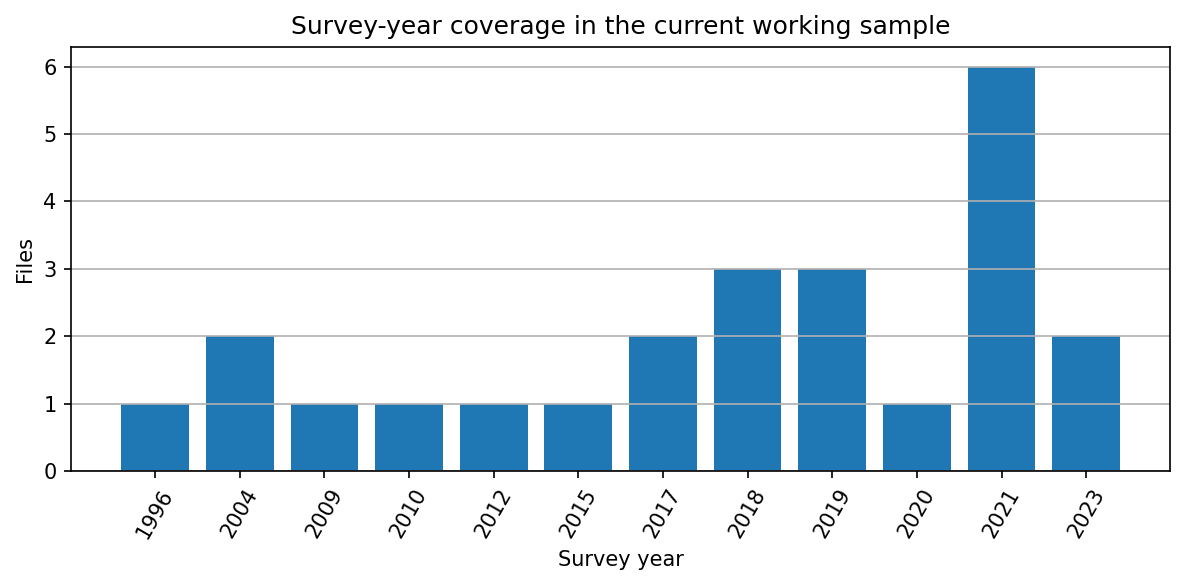

Hs                                 PeakPeriod                    \
          count     min  median    mean     max      count      min   median   
family                                                                         
stats         2  1.3206  2.1249  2.1249  2.9293          2  10.0000  10.4054   
tri_full      2  0.5884  0.7919  0.7919  0.9954          2   8.1633   9.0816   
tri_small    20  0.3247  0.9466  1.0317  1.9195         20   5.4795  10.0000   

                               DX                                 TOTAL_TIME  \
              mean      max count     min  median    mean     max      count   
family                                                                         
stats      10.4054  10.8108     2  1.1974  1.2513  1.2513  1.3051          2   
tri_full    9.0816  10.0000     2  0.9496  1.0735  1.0735  1.1974          2   
tri_small  10.9096  16.0000    20  0.5699  1.1974  1.3126  1.9824         20   

                                                      t_prop            \
                 min     median       mean        max  count       min   
family                                                                   
stats      1170.2830  1209.3646  1209.3646  1248.4462      2  146.2854   
tri_full   1226.2471  1328.0917  1328.0917  1429.9363      2  153.2809   
tri_small  1094.8197  1224.7770  1238.6827  1484.9807     20  136.8525   

                                         
             median      mean       max  
family                                   
stats      151.1706  151.1706  156.0558  
tri_full   166.0115  166.0115  178.7420  
tri_small  153.0971  154.8353  185.6226

In [8]:
date_df = inventory_df.dropna(subset=["ba_date"]).copy()
if not date_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    year_counts = date_df["ba_date"].dt.year.value_counts().sort_index()
    ax.bar(year_counts.index.astype(str), year_counts.values)
    ax.set_title("Survey-year coverage in the current working sample")
    ax.set_xlabel("Survey year")
    ax.set_ylabel("Files")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(True, axis="y")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_survey_year_counts.png", dpi=180, bbox_inches="tight")
    plt.show()

numeric_summary = (
    inventory_df.groupby("family")[["Hs", "PeakPeriod", "DX", "TOTAL_TIME", "t_prop"]]
    .agg(["count", "min", "median", "mean", "max"])
    .round(4)
)
numeric_summary.to_csv(OUTPUT_DIR / "family_numeric_summary.csv")
display(numeric_summary)

## 3. Reduced-statistics (`stats`) branch
The `stats` files are the compact, ML-friendly products already resampled to a standard 200-point representation. (which will not be used in the final version of the project)

In [9]:
stats_files = [(src, path) for src, path in nc_files if inventory_df.loc[inventory_df["relative_path"] == str(path), "family"].iloc[0] == "stats"]
print(f"stats files: {len(stats_files)}")

def extract_stats_products(path: Path, source_name: str):
    with open_ds(path) as ds:
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}

        x_interp = ds["X_interp"].values.astype(float)
        z_interp = ds["Z_interp"].values.astype(float)
        sk_int = ds["Sk_int"].values.astype(float)
        as_int = ds["As_int"].values.astype(float)

        row = {
            "source_name": source_name,
            "file": path.name,
            "family": "stats",
            "combo_num": attrs.get("COMBO_NUM"),
            "iter": attrs.get("ITER"),
            "surveyNumber": attrs.get("surveyNumber"),
            "profileNumber": attrs.get("profileNumber"),
            "ba_date_str": attrs.get("ba_date_str"),
            "sp_date_str": attrs.get("sp_date_str"),
            "Hs": attrs.get("Hs"),
            "PeakPeriod": attrs.get("PeakPeriod"),
            "DX": attrs.get("DX"),
            "TOTAL_TIME": attrs.get("TOTAL_TIME"),
            "t_prop": attrs.get("t_prop"),
            "x_interp_min": float(np.nanmin(x_interp)),
            "x_interp_max": float(np.nanmax(x_interp)),
            "z_interp_min": float(np.nanmin(z_interp)),
            "z_interp_max": float(np.nanmax(z_interp)),
            "sk_int_min": float(np.nanmin(sk_int)),
            "sk_int_max": float(np.nanmax(sk_int)),
            "as_int_min": float(np.nanmin(as_int)),
            "as_int_max": float(np.nanmax(as_int)),
        }

        interp_long = pd.DataFrame(
            {
                "source_name": source_name,
                "file": path.name,
                "combo_num": attrs.get("COMBO_NUM"),
                "profileNumber": attrs.get("profileNumber"),
                "x_interp": x_interp,
                "z_interp": z_interp,
                "sk_int": sk_int,
                "as_int": as_int,
            }
        )
        return row, interp_long

stats_rows, stats_profiles = [], []
for source_name, path in stats_files:
    row, prof = extract_stats_products(path, source_name)
    stats_rows.append(row)
    stats_profiles.append(prof)

stats_features_df = pd.DataFrame(stats_rows).sort_values(["combo_num", "file"]).reset_index(drop=True)
stats_profiles_df = pd.concat(stats_profiles, ignore_index=True) if stats_profiles else pd.DataFrame()

if EXPORT_PROCESSED_TABLES:
    stats_features_df.to_csv(OUTPUT_DIR / "stats_metadata_features.csv", index=False)
    if EXPORT_LONG_TABLES and not stats_profiles_df.empty:
        stats_profiles_df.to_csv(OUTPUT_DIR / "stats_interp_profiles_long.csv.gz", index=False, compression="gzip")

display(stats_features_df)

stats files: 2


,source_name,file,family,combo_num,iter,surveyNumber,profileNumber,ba_date_str,sp_date_str,Hs,PeakPeriod,DX,TOTAL_TIME,t_prop,x_interp_min,x_interp_max,z_interp_min,z_interp_max,sk_int_min,sk_int_max,as_int_min,as_int_max
0,Sample Data.zip,stats_00001.nc,stats,1,1,1270.0,274.0,04/17/2023,01/21/2002 06:00,2.9293,10.0000,1.1974,1170.2830,146.2854,0.0,737.5912,0.0467,9.2274,-0.0266,1.5101,-1.0990,0.1718
1,Sample Data.zip,stats_02930.nc,stats,2930,2930,1105.0,-91.0,09/15/2015,01/21/2002 06:00,1.3206,10.8108,1.3051,1248.4462,156.0558,0.0,793.5225,0.0554,8.7713,-0.0241,0.9546,-1.0157,0.2093


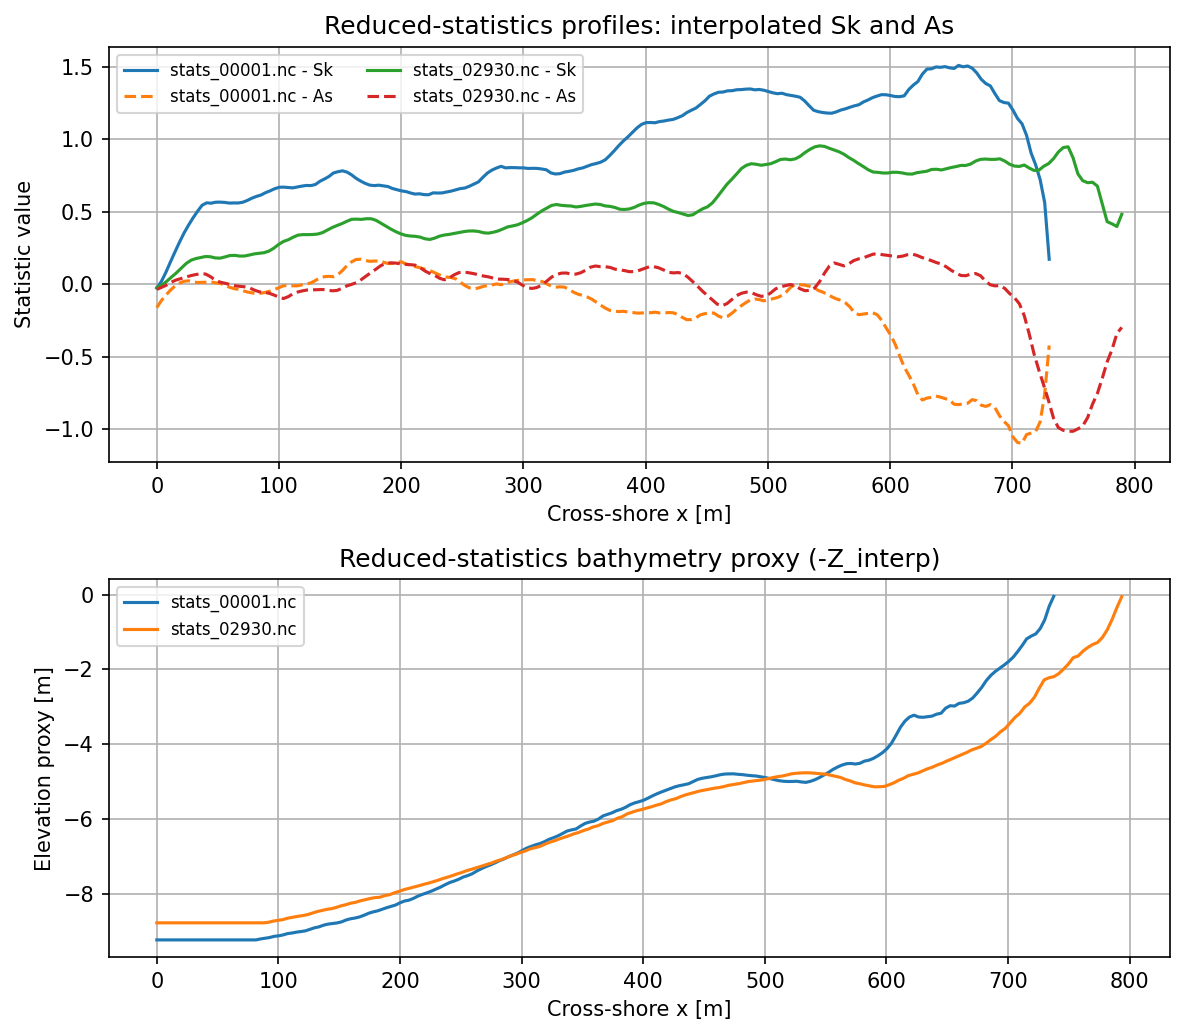

In [10]:
if not stats_profiles_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=False, height_ratios=[1.1, 1.0])

    for file_name, sub in stats_profiles_df.groupby("file"):
        axes[0].plot(sub["x_interp"], sub["sk_int"], label=f"{file_name} - Sk")
        axes[0].plot(sub["x_interp"], sub["as_int"], linestyle="--", label=f"{file_name} - As")

    axes[0].set_title("Reduced-statistics profiles: interpolated Sk and As")
    axes[0].set_xlabel("Cross-shore x [m]")
    axes[0].set_ylabel("Statistic value")
    axes[0].grid(True)
    axes[0].legend(fontsize=8, ncol=2)

    for file_name, sub in stats_profiles_df.groupby("file"):
        axes[1].plot(sub["x_interp"], -sub["z_interp"], label=file_name)

    axes[1].set_title("Reduced-statistics bathymetry proxy (-Z_interp)")
    axes[1].set_xlabel("Cross-shore x [m]")
    axes[1].set_ylabel("Elevation proxy [m]")
    axes[1].grid(True)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_stats_profiles_overlay.png", dpi=180, bbox_inches="tight")
    plt.show()

## 4. Raw time-series branch (`tri_full` + `tri_small`)
The raw files are processed one file at a time and reduced to standardized centerline summaries.  
This is the branch to create reproducible hydrodynamic EDA without keeping the full native time series in memory.

In [11]:
raw_files = [(src, path) for src, path in nc_files if inventory_df.loc[inventory_df["relative_path"] == str(path), "family"].iloc[0] in ("tri_full", "tri_small")]
print(f"raw files: {len(raw_files)}")

def select_centerline(arr, y_index=ANALYSIS_Y_INDEX):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        if arr.shape[1] <= 5 and arr.shape[0] > arr.shape[1]:
            return arr[:, min(y_index, arr.shape[1] - 1)]
        return arr
    if arr.ndim == 3:
        axis = int(np.argmin(arr.shape))
        if arr.shape[axis] <= 5:
            return np.take(arr, indices=min(y_index, arr.shape[axis] - 1), axis=axis)
    raise ValueError(f"Cannot infer centerline axis from shape {arr.shape}")

def ensure_time_first(arr, x_len):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    if arr.shape[-1] == x_len:
        return arr.reshape(-1, x_len)
    if arr.shape[0] == x_len:
        return np.moveaxis(arr, 0, -1).reshape(-1, x_len)
    raise ValueError(f"Cannot align array of shape {arr.shape} to x_len={x_len}")

def process_raw_file(path: Path, source_name: str):
    with open_ds(path) as ds:
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        family = infer_family_from_vars(ds.data_vars)

        x = ds["X"].values.astype(float)
        z = select_centerline(ds["Z"].values.astype(float))
        eta = ensure_time_first(select_centerline(ds["eta"].values.astype(float)), len(x))
        mask = ensure_time_first(select_centerline(ds["mask"].values.astype(float)), len(x))
        nubrk = ensure_time_first(select_centerline(ds["nubrk"].values.astype(float)), len(x))

        t = ds["t_FW"].values.astype(float) if "t_FW" in ds.coords else np.arange(eta.shape[0], dtype=float)
        start_idx = 0
        if pd.notna(attrs.get("t_prop")):
            start_idx = int(np.searchsorted(t, float(attrs.get("t_prop"))))

        eta_use = eta[start_idx:]
        mask_use = mask[start_idx:]
        nubrk_use = nubrk[start_idx:]

        wet_fraction = np.nanmean(mask_use > 0.5, axis=0)
        breaking_fraction = np.nanmean(nubrk_use > 0, axis=0)
        eta_abs_mean = np.nanmean(np.abs(eta_use), axis=0)

        extra_curves = {}
        if "U_undertow" in ds.data_vars:
            undertow = ensure_time_first(select_centerline(ds["U_undertow"].values.astype(float)), len(x))
            extra_curves["undertow_mean"] = np.nanmean(undertow[start_idx:], axis=0)
        if "roller" in ds.data_vars:
            roller = ensure_time_first(select_centerline(ds["roller"].values.astype(float)), len(x))
            extra_curves["roller_mean"] = np.nanmean(roller[start_idx:], axis=0)

        raw_curve = pd.DataFrame(
            {
                "x": x,
                "z": z,
                "wet_fraction": wet_fraction,
                "breaking_fraction": breaking_fraction,
                "eta_abs_mean": eta_abs_mean,
            }
        )
        for key, values in extra_curves.items():
            raw_curve[key] = values

        wet_mask = raw_curve["wet_fraction"] > 0
        wet_domain = raw_curve.loc[wet_mask].copy()
        if wet_domain.empty:
            wet_domain = raw_curve.copy()

        x0 = float(wet_domain["x"].min())
        x1 = float(wet_domain["x"].max())
        norm_grid = np.linspace(0.0, 1.0, NORM_GRID_SIZE)
        wet_domain["x_norm"] = 0.0 if x1 == x0 else (wet_domain["x"] - x0) / (x1 - x0)

        interp_cols = ["z", "wet_fraction", "breaking_fraction", "eta_abs_mean"]
        for maybe_col in ["undertow_mean", "roller_mean"]:
            if maybe_col in wet_domain.columns:
                interp_cols.append(maybe_col)

        interp_payload = {}
        for col in interp_cols:
            interp_payload[col] = np.interp(norm_grid, wet_domain["x_norm"], wet_domain[col])

        norm_profile = pd.DataFrame(
            {
                "source_name": source_name,
                "file": path.name,
                "family": family,
                "x_norm": norm_grid,
                **interp_payload,
            }
        )

        row = {
            "source_name": source_name,
            "file": path.name,
            "family": family,
            "combo_num": attrs.get("COMBO_NUM"),
            "iter": attrs.get("ITER"),
            "surveyNumber": attrs.get("surveyNumber"),
            "profileNumber": attrs.get("profileNumber"),
            "ba_date_str": attrs.get("ba_date_str"),
            "sp_date_str": attrs.get("sp_date_str"),
            "Hs": attrs.get("Hs"),
            "PeakPeriod": attrs.get("PeakPeriod"),
            "DX": attrs.get("DX"),
            "TOTAL_TIME": attrs.get("TOTAL_TIME"),
            "t_prop": attrs.get("t_prop"),
            "x_min": float(np.nanmin(x)),
            "x_max": float(np.nanmax(x)),
            "z_min": float(np.nanmin(z)),
            "z_max": float(np.nanmax(z)),
            "wet_fraction_mean": float(np.nanmean(wet_fraction)),
            "wet_fraction_min": float(np.nanmin(wet_fraction)),
            "wet_fraction_max": float(np.nanmax(wet_fraction)),
            "breaking_fraction_mean": float(np.nanmean(breaking_fraction)),
            "breaking_fraction_max": float(np.nanmax(breaking_fraction)),
            "eta_abs_mean_mean": float(np.nanmean(eta_abs_mean)),
            "eta_abs_mean_max": float(np.nanmax(eta_abs_mean)),
            "has_undertow": "undertow_mean" in extra_curves,
            "has_roller": "roller_mean" in extra_curves,
        }

        return row, norm_profile, raw_curve, attrs

raw_rows, raw_norm_profiles, raw_examples = [], [], []
for idx, (source_name, path) in enumerate(raw_files, start=1):
    if idx % 50 == 0 or idx == 1 or idx == len(raw_files):
        print(f"Processing raw file {idx:,} / {len(raw_files):,}")
    row, norm_profile, raw_curve, attrs = process_raw_file(path, source_name)
    raw_rows.append(row)
    raw_norm_profiles.append(norm_profile)

    if len(raw_examples) < RAW_EXAMPLE_COUNT:
        raw_examples.append((path.name, raw_curve.copy(), attrs.copy()))

raw_features_df = pd.DataFrame(raw_rows).sort_values(["combo_num", "file"]).reset_index(drop=True)
raw_norm_profiles_df = pd.concat(raw_norm_profiles, ignore_index=True) if raw_norm_profiles else pd.DataFrame()

if EXPORT_PROCESSED_TABLES:
    raw_features_df.to_csv(OUTPUT_DIR / "raw_metadata_features.csv", index=False)
    if EXPORT_LONG_TABLES and not raw_norm_profiles_df.empty:
        raw_norm_profiles_df.to_csv(OUTPUT_DIR / "raw_norm_profiles_long.csv.gz", index=False, compression="gzip")

display(raw_features_df.head())
print(f"\nRaw standardized profiles rows: {len(raw_norm_profiles_df):,}")

raw files: 22
Processing raw file 1 / 22


Processing raw file 22 / 22


,source_name,file,family,combo_num,iter,surveyNumber,profileNumber,ba_date_str,sp_date_str,Hs,PeakPeriod,DX,TOTAL_TIME,t_prop,x_min,x_max,z_min,z_max,wet_fraction_mean,wet_fraction_min,wet_fraction_max,breaking_fraction_mean,breaking_fraction_max,eta_abs_mean_mean,eta_abs_mean_max,has_undertow,has_roller
0,temp_2.zip,nc_small_ali_00001.nc,tri_small,1,1,1069.0,777.0,02/14/2012,01/21/2002 06:00,1.6285,14.2857,1.7603,1152.8393,144.1049,0.0,1274.4531,-1.0932,9.0488,0.9934,0.1567,1.0,6.6043e-05,0.0119,0.2833,1.1127,False,False
1,temp_2.zip,nc_small_ali_00002.nc,tri_small,2,2,1209.0,1052.0,08/23/2021,01/21/2002 06:00,0.9954,10.0000,1.1974,1226.2471,153.2809,0.0,1071.6625,-1.9080,8.5010,0.9708,0.0000,1.0,2.1376e-05,0.0022,0.2190,1.8580,False,False
2,Sample Data.zip,tri_00002.nc,tri_full,2,2,1209.0,1052.0,08/23/2021,01/21/2002 06:00,0.9954,10.0000,1.1974,1226.2471,153.2809,0.0,1071.6625,-1.9080,8.5010,0.9708,0.0000,1.0,2.1376e-05,0.0022,0.2190,1.8580,True,True
3,temp_2.zip,nc_small_ali_00003.nc,tri_small,3,3,1181.0,1.0,02/18/2020,01/21/2002 06:00,0.6457,16.0000,1.9824,1128.8643,141.1080,0.0,1336.1165,-1.9473,8.3077,0.9702,0.0000,1.0,0.0000e+00,0.0000,0.1381,1.8973,False,False
4,temp_2.zip,nc_small_ali_00004.nc,tri_small,4,4,1135.0,274.0,06/06/2017,01/21/2002 06:00,0.4826,16.0000,1.9824,1094.8197,136.8525,0.0,1294.4868,-2.9734,8.2125,0.9731,0.0000,1.0,0.0000e+00,0.0000,0.1317,2.9235,False,False



Raw standardized profiles rows: 4,400


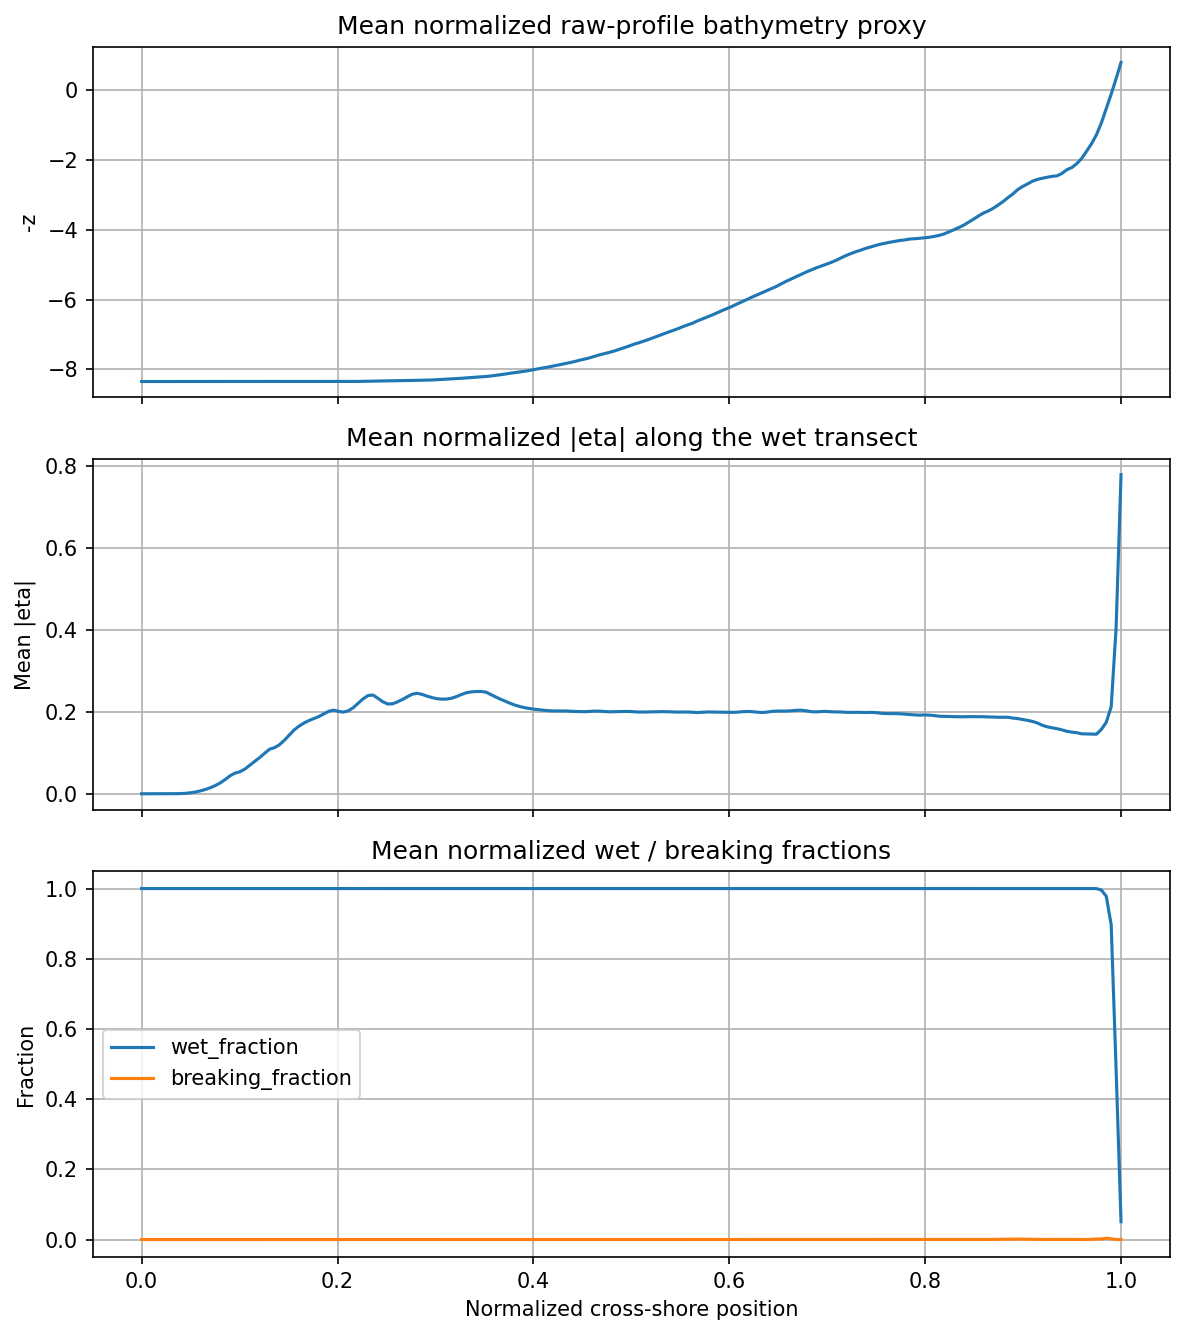

In [12]:
if not raw_norm_profiles_df.empty:
    mean_norm = raw_norm_profiles_df.groupby("x_norm")[["z", "wet_fraction", "breaking_fraction", "eta_abs_mean"]].mean().reset_index()

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), dpi=150, sharex=True, height_ratios=[1.0, 1.0, 1.1])

    axes[0].plot(mean_norm["x_norm"], -mean_norm["z"])
    axes[0].set_title("Mean normalized raw-profile bathymetry proxy")
    axes[0].set_ylabel("-z")
    axes[0].grid(True)

    axes[1].plot(mean_norm["x_norm"], mean_norm["eta_abs_mean"])
    axes[1].set_title("Mean normalized |eta| along the wet transect")
    axes[1].set_ylabel("Mean |eta|")
    axes[1].grid(True)

    axes[2].plot(mean_norm["x_norm"], mean_norm["wet_fraction"], label="wet_fraction")
    axes[2].plot(mean_norm["x_norm"], mean_norm["breaking_fraction"], label="breaking_fraction")
    axes[2].set_title("Mean normalized wet / breaking fractions")
    axes[2].set_xlabel("Normalized cross-shore position")
    axes[2].set_ylabel("Fraction")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_raw_mean_normalized_curves.png", dpi=180, bbox_inches="tight")
    plt.show()

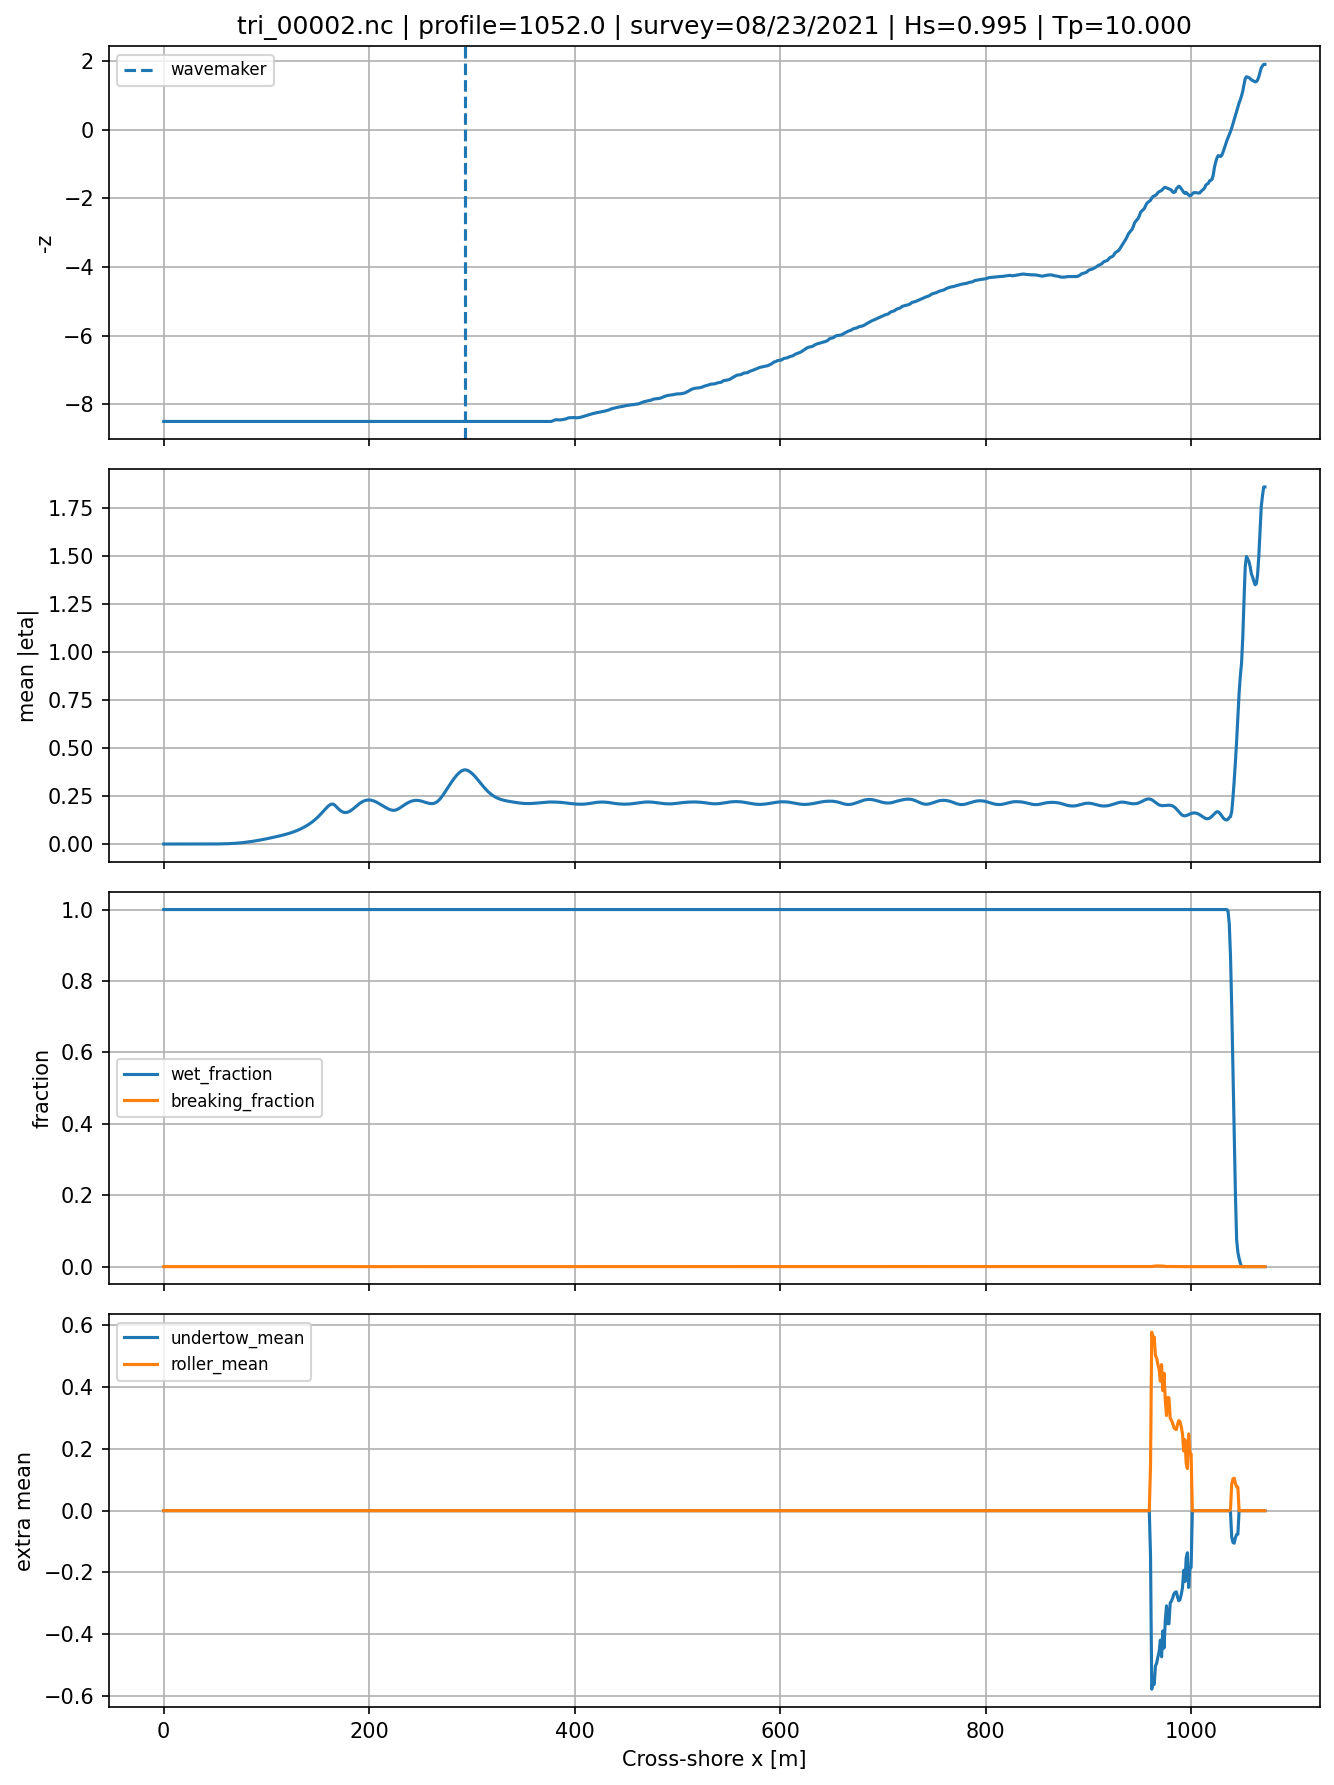

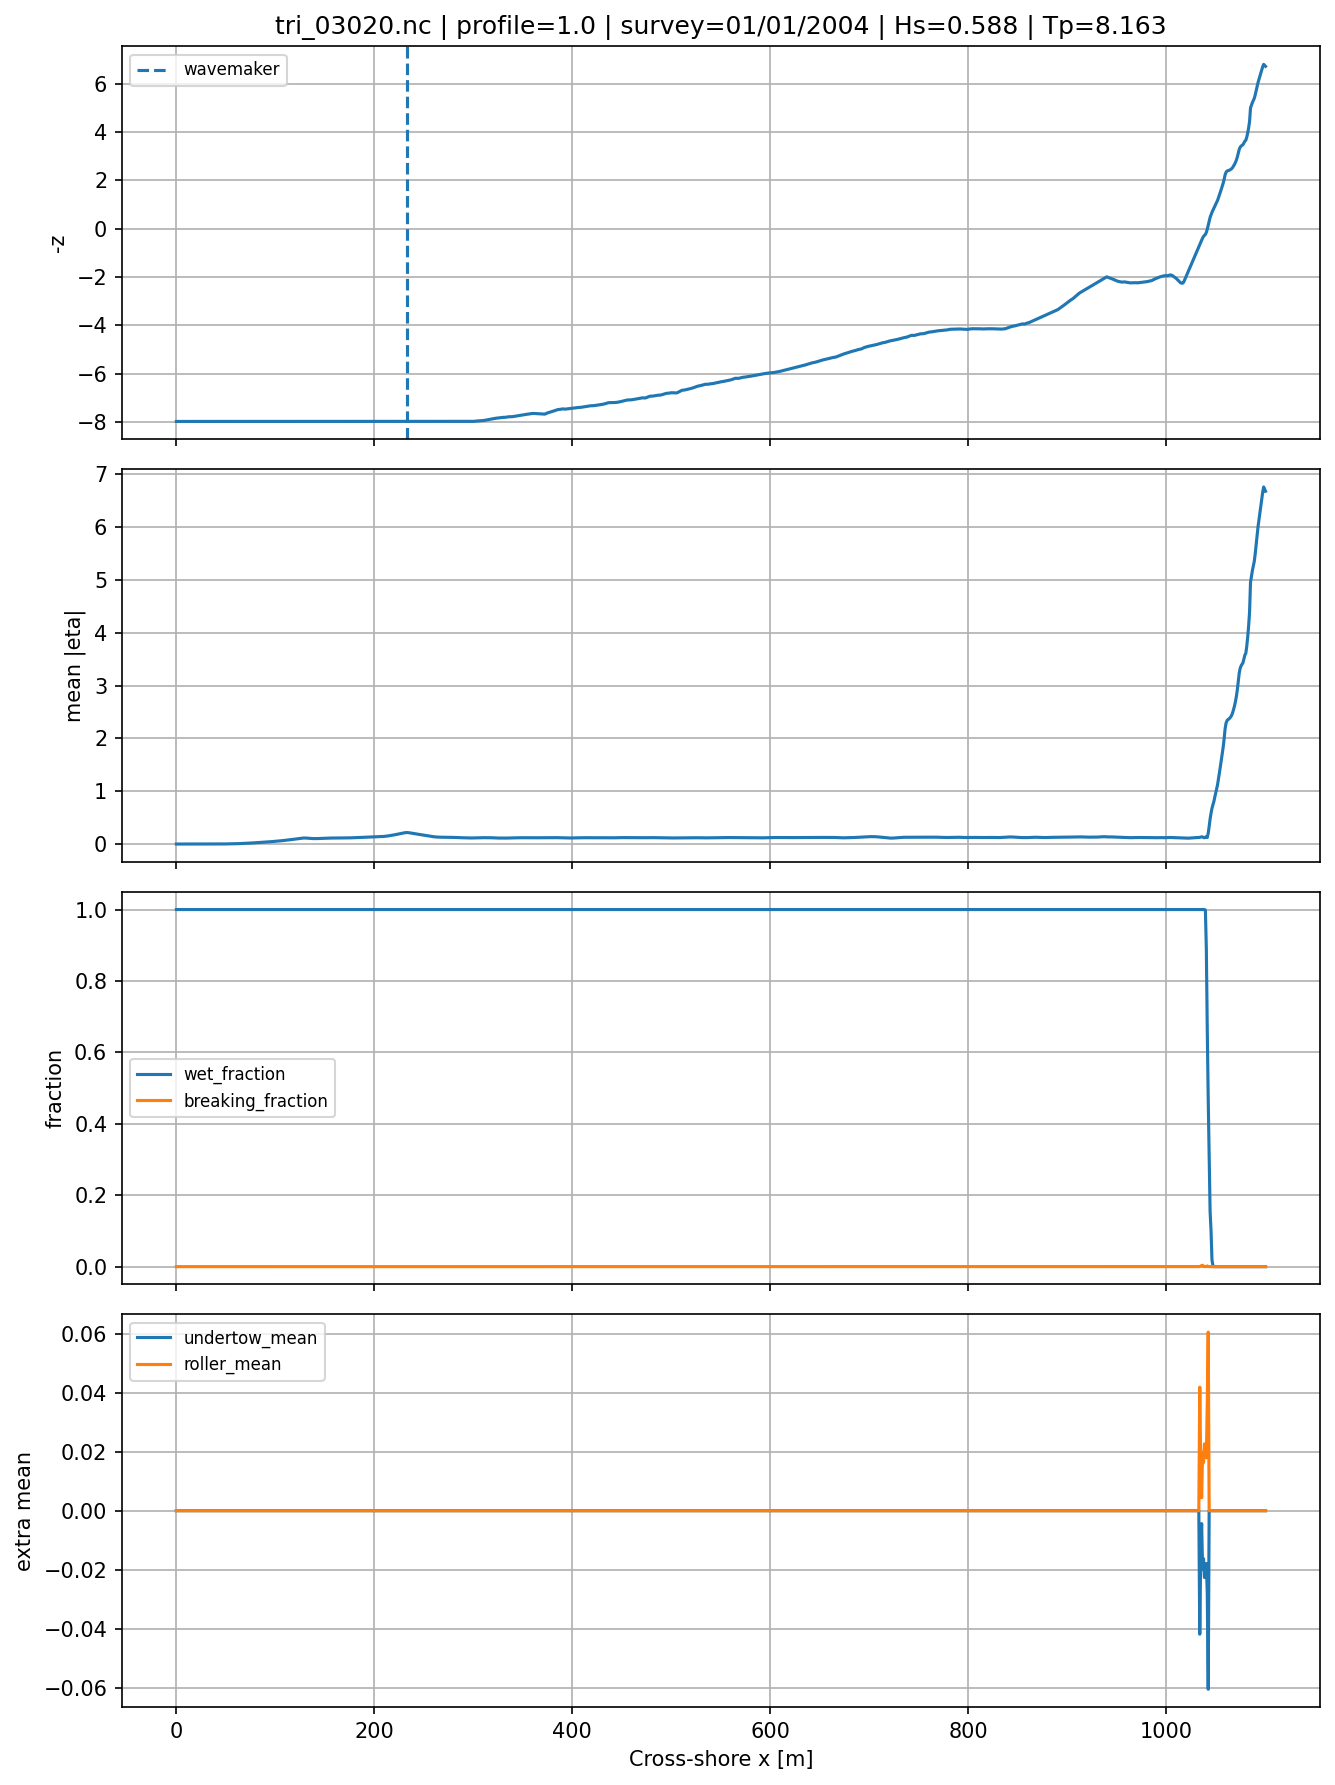

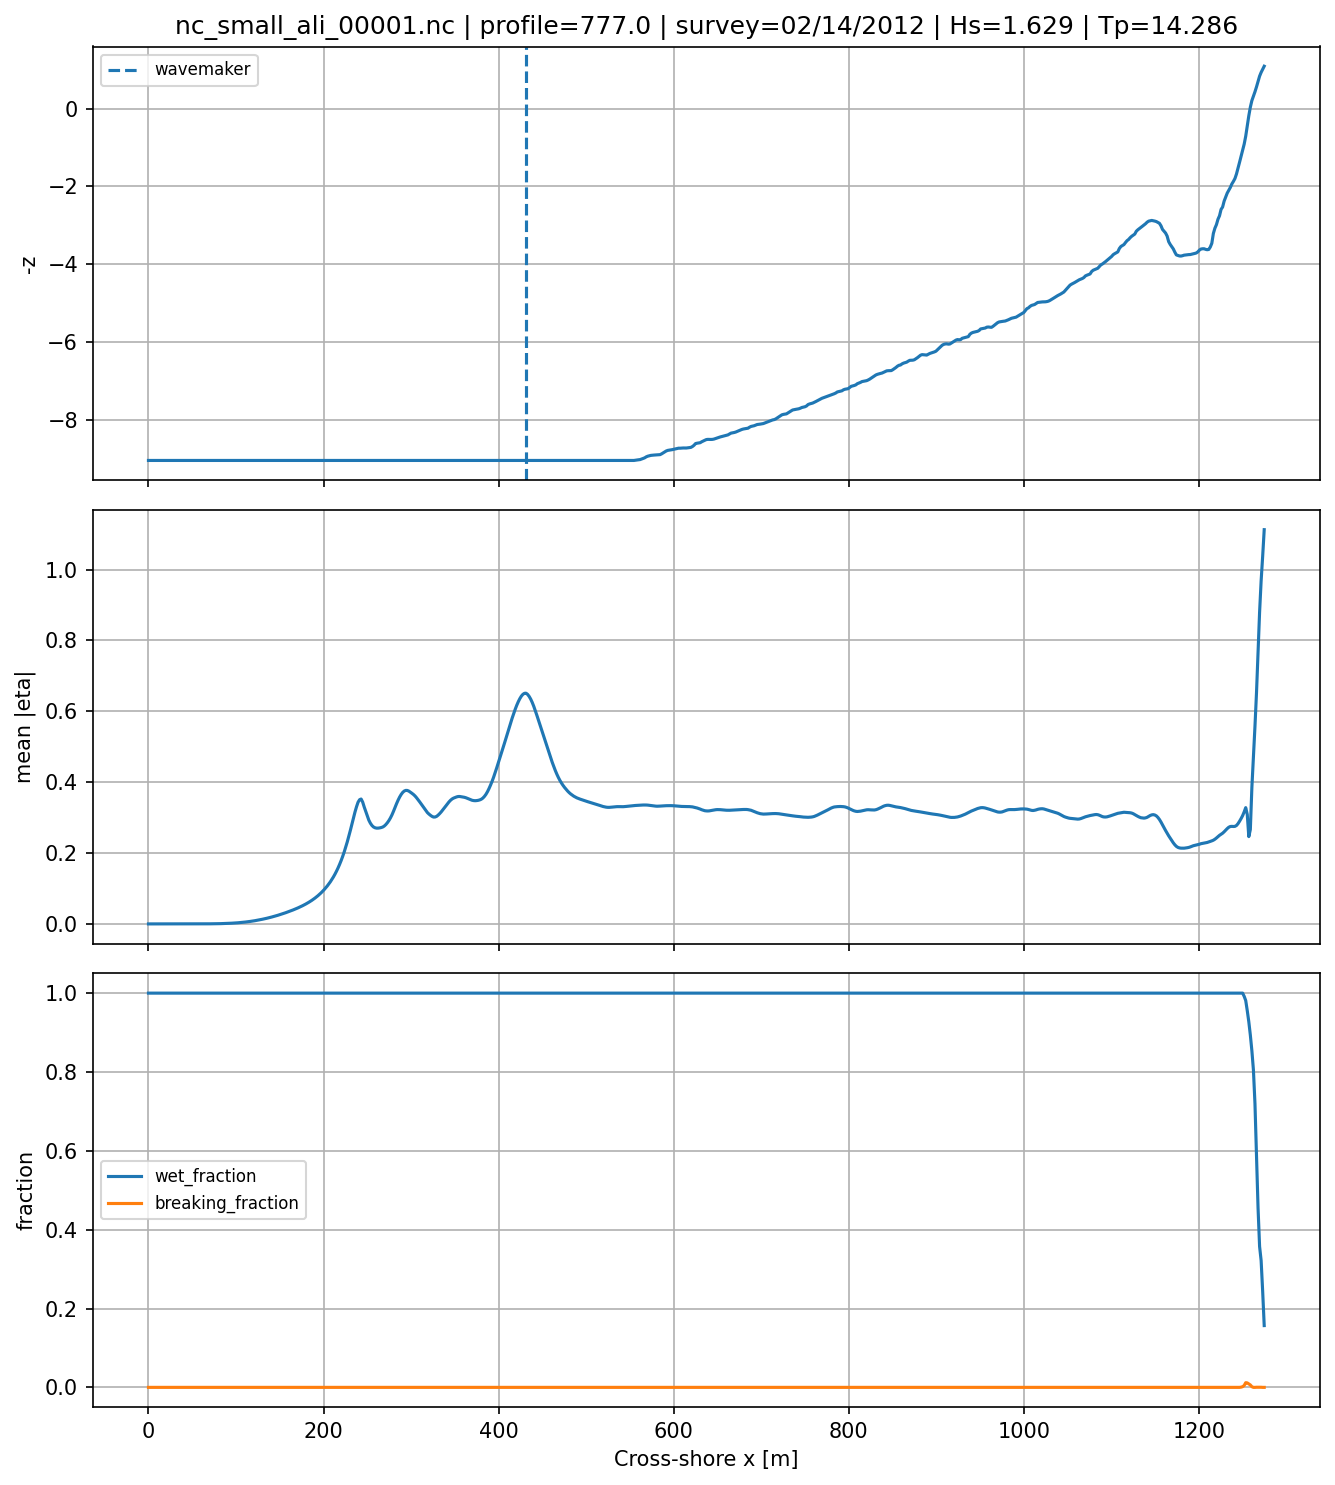

In [13]:
for file_name, curve_df, attrs in raw_examples:
    cols = 2 if {"undertow_mean", "roller_mean"}.issubset(curve_df.columns) else 1
    fig, axes = plt.subplots(3 if cols == 1 else 4, 1, figsize=(9, 10 if cols == 1 else 12), dpi=150, sharex=True)
    axes = np.atleast_1d(axes)

    axes[0].plot(curve_df["x"], -curve_df["z"])
    if pd.notna(attrs.get("Xc_WK")):
        axes[0].axvline(float(attrs.get("Xc_WK")), linestyle="--", label="wavemaker")
        axes[0].legend(fontsize=8)
    axes[0].set_title(
        f"{file_name} | profile={attrs.get('profileNumber')} | survey={attrs.get('ba_date_str')} | "
        f"Hs={attrs.get('Hs'):.3f} | Tp={attrs.get('PeakPeriod'):.3f}"
    )
    axes[0].set_ylabel("-z")
    axes[0].grid(True)

    axes[1].plot(curve_df["x"], curve_df["eta_abs_mean"])
    axes[1].set_ylabel("mean |eta|")
    axes[1].grid(True)

    axes[2].plot(curve_df["x"], curve_df["wet_fraction"], label="wet_fraction")
    axes[2].plot(curve_df["x"], curve_df["breaking_fraction"], label="breaking_fraction")
    axes[2].set_ylabel("fraction")
    axes[2].grid(True)
    axes[2].legend(fontsize=8)

    ax_idx = 3
    if "undertow_mean" in curve_df.columns:
        axes[ax_idx].plot(curve_df["x"], curve_df["undertow_mean"], label="undertow_mean")
        if "roller_mean" in curve_df.columns:
            axes[ax_idx].plot(curve_df["x"], curve_df["roller_mean"], label="roller_mean")
        axes[ax_idx].set_ylabel("extra mean")
        axes[ax_idx].grid(True)
        axes[ax_idx].legend(fontsize=8)
        axes[ax_idx].set_xlabel("Cross-shore x [m]")
    else:
        axes[2].set_xlabel("Cross-shore x [m]")

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"example_{file_name.replace('.nc','')}_overview.png", dpi=180, bbox_inches="tight")
    plt.show()

## 5. Spectral table and processing manifest
This final block creates compact outputs that can be used directly in the write-up and downstream feature engineering.

In [14]:
def extract_spectra_long(path: Path, source_name: str):
    with open_ds(path) as ds:
        attrs = {k: scalarize(v) for k, v in ds.attrs.items()}
        return pd.DataFrame(
            {
                "source_name": source_name,
                "file": path.name,
                "family": infer_family_from_vars(ds.data_vars),
                "combo_num": attrs.get("COMBO_NUM"),
                "profileNumber": attrs.get("profileNumber"),
                "surveyNumber": attrs.get("surveyNumber"),
                "Hs": attrs.get("Hs"),
                "PeakPeriod": attrs.get("PeakPeriod"),
                "period": ds["period"].values.astype(float),
                "amp": ds["amp"].values.astype(float),
                "phase": ds["phase"].values.astype(float),
            }
        )

spectra_frames = [extract_spectra_long(path, source_name) for source_name, path in nc_files]
spectra_df = pd.concat(spectra_frames, ignore_index=True) if spectra_frames else pd.DataFrame()

if EXPORT_PROCESSED_TABLES and not spectra_df.empty:
    spectra_df.to_csv(OUTPUT_DIR / "spectra_long.csv.gz", index=False, compression="gzip")

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "root": str(ROOT),
    "sources": [str(p) for p in sources],
    "materialized_sources": [{**item, "path": str(item["path"])} for item in materialized],
    "netcdf_file_count": len(nc_files),
    "family_counts": inventory_df["family"].value_counts(dropna=False).to_dict(),
    "generated_outputs": sorted([p.name for p in OUTPUT_DIR.glob("*") if p.is_file()]),
    "notes": [
        "stats branch kept separate from raw branch",
        "raw branch supports both tri_full and tri_small schema variants",
        "negative profileNumber can be valid in Duck FRF coordinates",
        "Z_orig is treated as advisory only because the sample provider notes a likely typo there",
        "raw files are reduced to standardized centerline summaries for scalable first-pass processing",
    ],
}
with open(OUTPUT_DIR / "processing_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Generated files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

print("\nSpectra head")
display(spectra_df.head())

Generated files:
 - family_numeric_summary.csv
 - figures
 - file_inventory.csv
 - processing_manifest.json
 - qa_findings.csv
 - raw_metadata_features.csv
 - raw_norm_profiles_long.csv.gz
 - schema_summary.csv
 - spectra_long.csv.gz
 - stats_interp_profiles_long.csv.gz
 - stats_metadata_features.csv

Spectra head


,source_name,file,family,combo_num,profileNumber,surveyNumber,Hs,PeakPeriod,period,amp,phase
0,Sample Data.zip,stats_00001.nc,stats,1,274.0,1270.0,2.9293,10.0,25.0000,0.0423,2.1300
1,Sample Data.zip,stats_00001.nc,stats,1,274.0,1270.0,2.9293,10.0,21.0526,0.0371,-0.5273
2,Sample Data.zip,stats_00001.nc,stats,1,274.0,1270.0,2.9293,10.0,18.1818,0.0361,-1.6895
3,Sample Data.zip,stats_00001.nc,stats,1,274.0,1270.0,2.9293,10.0,16.0000,0.0408,0.9991
4,Sample Data.zip,stats_00001.nc,stats,1,274.0,1270.0,2.9293,10.0,14.2857,0.0798,-2.6648
